# Wavelet-ICA EEG Denoising

**Dataset:** EEGDenoiseNet (Zhang et al., 2021) — HDF5 format  
**Artifact combos:** EMG, EOG, ECG, and all mixed combinations (7 total)  
**Signal length:** 512 samples @ 256 Hz (2 seconds)  
**Metrics:** MSE · RMSE · RRMSE · SNR (dB) · Spectral Loss  

**Pipeline:**  
1. Load noisy EEG from HDF5  
2. Wavelet decomposition (db4, level 6)  
3. FastICA on detail coefficients  
4. Component rejection via kurtosis thresholding  
5. Wavelet reconstruction  
6. Evaluate all metrics per combo and split

## 1 · Install & Import

In [25]:
# Install any missing dependencies (Kaggle usually has all of these)
import subprocess, sys
def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

try:
    import pywt
except ImportError:
    pip_install('PyWavelets')

try:
    import h5py
except ImportError:
    pip_install('h5py')

print('All dependencies ready.')

All dependencies ready.


In [26]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import h5py
import pywt
from scipy.stats import kurtosis
from sklearn.decomposition import FastICA
from tqdm.auto import tqdm, trange
import time

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})

SEED = 42
np.random.seed(SEED)

print('Imports OK')

Imports OK


## 2 · Configuration

In [27]:
# ─────────────────────────────────────────────
#  CONFIG  ← edit paths / hyperparams here
# ─────────────────────────────────────────────

# Root directory where your HDF5 files live on Kaggle
# Typical Kaggle input path: /kaggle/input/<dataset-slug>/
DATA_DIR = '/kaggle/input/datasets/lucky3663/eegdenoise'   # ← update to your dataset slug

# Artifact combinations (all 7 from Table I)
COMBOS = ['emg', 'eog', 'ecg', 'emg_eog', 'emg_ecg', 'eog_ecg', 'emg_eog_ecg']
SPLITS = ['test']

# Wavelet parameters
WAVELET   = 'db4'   # Daubechies-4 — standard for EEG
LEVEL     = 6       # decomposition levels

# ICA / artifact rejection
N_COMPONENTS = None   # None → auto (= number of detail bands)
KURTOSIS_THRESH = 3.0 # reject components with |excess kurtosis| > threshold
MAX_ITER  = 500
ICA_TOL   = 1e-4

# Evaluation: process at most this many samples per split for speed
# Set to None to evaluate on all samples
MAX_EVAL_SAMPLES = None

FS = 256  # sampling frequency (Hz)

print(f'DATA_DIR : {DATA_DIR}')
print(f'Wavelet  : {WAVELET}  Level: {LEVEL}')
print(f'Kurtosis threshold: {KURTOSIS_THRESH}')

DATA_DIR : /kaggle/input/datasets/lucky3663/eegdenoise
Wavelet  : db4  Level: 6
Kurtosis threshold: 3.0


## 3 · Helper Utilities

In [28]:
# ── Data loading ──────────────────────────────────────────────────────────────

def load_h5(combo: str, split: str, data_dir: str = DATA_DIR):
    """Load clean and noisy arrays from an HDF5 file."""
    path = os.path.join(data_dir, f'{combo}_{split}.h5')
    if not os.path.exists(path):
        raise FileNotFoundError(f'File not found: {path}')
    with h5py.File(path, 'r') as f:
        clean = f['clean'][:]   # (N, 512) float32
        noisy = f['noisy'][:]   # (N, 512) float32
    return clean.astype(np.float32), noisy.astype(np.float32)


def list_available_files(data_dir: str = DATA_DIR):
    """Print all HDF5 files found in data_dir."""
    files = sorted(f for f in os.listdir(data_dir) if f.endswith('.h5'))
    print(f'Found {len(files)} .h5 files in {data_dir}:')
    for f in files:
        size_mb = os.path.getsize(os.path.join(data_dir, f)) / 1e6
        print(f'  {f:<30}  {size_mb:.1f} MB')
    return files

print('Data utilities defined.')

Data utilities defined.


In [29]:
# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_mse(clean: np.ndarray, denoised: np.ndarray) -> float:
    """Mean Squared Error."""
    return float(np.mean((clean - denoised) ** 2))


def compute_rmse(clean: np.ndarray, denoised: np.ndarray) -> float:
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((clean - denoised) ** 2)))


def compute_rrmse(clean: np.ndarray, denoised: np.ndarray, eps: float = 1e-10) -> float:
    """Relative RMSE = RMSE / RMS(clean).
    Lower is better; 0 = perfect reconstruction.
    """
    rmse  = np.sqrt(np.mean((clean - denoised) ** 2, axis=-1))
    rms_c = np.sqrt(np.mean(clean ** 2, axis=-1)) + eps
    return float(np.mean(rmse / rms_c))


def compute_snr_db(clean: np.ndarray, denoised: np.ndarray, eps: float = 1e-10) -> float:
    """Output SNR in dB = 10 * log10( power(clean) / power(noise_residual) ).
    Higher is better.
    """
    signal_power = np.mean(clean ** 2, axis=-1)
    noise_power  = np.mean((clean - denoised) ** 2, axis=-1) + eps
    snr_linear   = signal_power / noise_power
    return float(np.mean(10 * np.log10(snr_linear + eps)))


def compute_spectral_loss(
    clean: np.ndarray,
    denoised: np.ndarray,
    fs: int = FS,
    eps: float = 1e-10
) -> float:
    """Spectral loss: mean absolute log-spectral distance (dB).
    Computed on the power spectral density (FFT magnitude squared).
    """
    n = clean.shape[-1]
    C = np.abs(np.fft.rfft(clean,  n=n)) ** 2  # (N, n//2+1)
    D = np.abs(np.fft.rfft(denoised, n=n)) ** 2
    log_diff = np.abs(10 * np.log10(C + eps) - 10 * np.log10(D + eps))
    return float(np.mean(log_diff))


def all_metrics(clean: np.ndarray, denoised: np.ndarray) -> dict:
    """Compute all five metrics at once."""
    return {
        'MSE'          : compute_mse(clean, denoised),
        'RMSE'         : compute_rmse(clean, denoised),
        'RRMSE'        : compute_rrmse(clean, denoised),
        'SNR_dB'       : compute_snr_db(clean, denoised),
        'SpectralLoss' : compute_spectral_loss(clean, denoised),
    }

print('Metrics defined.')

Metrics defined.


In [30]:
# ── Wavelet-ICA core ──────────────────────────────────────────────────────────

def wavelet_decompose(signal_1d: np.ndarray, wavelet: str, level: int):
    """Return wavedec coefficient list (cA_L, cD_L, …, cD_1)."""
    return pywt.wavedec(signal_1d, wavelet=wavelet, level=level)


def wavelet_reconstruct(coeffs: list, wavelet: str, length: int) -> np.ndarray:
    """Reconstruct signal from coefficient list and trim/pad to `length`."""
    rec = pywt.waverec(coeffs, wavelet=wavelet)
    return rec[:length]  # trim extra sample from odd-length inputs


def reject_artifact_components(
    components: np.ndarray,
    mixing_matrix: np.ndarray,
    kurtosis_thresh: float = KURTOSIS_THRESH
) -> np.ndarray:
    """Zero out ICA components whose excess kurtosis exceeds the threshold.

    Parameters
    ----------
    components    : (n_components, n_samples)  — ICA source matrix
    mixing_matrix : (n_features,  n_components) — A matrix from FastICA
    kurtosis_thresh : scalar — components with |kurt| > thresh are removed

    Returns
    -------
    reconstructed : (n_features, n_samples)  — cleaned feature matrix
    """
    kurt = kurtosis(components, axis=1, fisher=True)  # excess kurtosis
    mask = np.abs(kurt) <= kurtosis_thresh             # True = keep
    cleaned_components = components * mask[:, np.newaxis]
    return mixing_matrix @ cleaned_components          # reconstruct


def wavelet_ica_denoise_single(
    noisy: np.ndarray,
    wavelet: str          = WAVELET,
    level: int            = LEVEL,
    n_components: int     = None,
    kurtosis_thresh: float= KURTOSIS_THRESH,
    max_iter: int         = MAX_ITER,
    tol: float            = ICA_TOL,
) -> np.ndarray:
    """Denoise a single EEG segment (1-D array) with Wavelet-ICA.

    Algorithm
    ---------
    1. Wavelet decompose → (cA, cD_L, …, cD_1)
    2. Stack all detail sub-bands into a feature matrix (L × time)
    3. FastICA decomposition
    4. Reject components with high kurtosis (likely artifact)
    5. Reconstruct detail sub-bands from cleaned sources
    6. Wavelet reconstruct with original approximation + cleaned details
    """
    L = noisy.shape[0]
    coeffs = wavelet_decompose(noisy, wavelet, level)
    # coeffs[0]  = cA (approximation, low-freq)
    # coeffs[1:] = cD_level, …, cD_1 (details, high→low freq)

    detail_coeffs = coeffs[1:]  # list of arrays, variable lengths
    n_bands = len(detail_coeffs)

    # Align all detail bands to the shortest length for ICA
    min_len = min(c.shape[0] for c in detail_coeffs)
    feature_matrix = np.array([c[:min_len] for c in detail_coeffs])  # (n_bands, min_len)

    n_comp = n_components if n_components else n_bands
    n_comp = min(n_comp, feature_matrix.shape[0], feature_matrix.shape[1])

    ica = FastICA(
        n_components=n_comp,
        random_state=SEED,
        max_iter=max_iter,
        tol=tol,
        whiten='unit-variance'
    )

    try:
        sources = ica.fit_transform(feature_matrix.T).T  # (n_comp, min_len)
        A = ica.mixing_                                   # (n_bands, n_comp)
        cleaned_features = reject_artifact_components(sources, A, kurtosis_thresh)  # (n_bands, min_len)

        # Restore full-length detail bands (pad cleaned portion, keep tail)
        cleaned_details = []
        for i, orig_c in enumerate(detail_coeffs):
            c_clean = orig_c.copy()
            if i < cleaned_features.shape[0]:
                c_clean[:min_len] = cleaned_features[i]
            cleaned_details.append(c_clean)

        new_coeffs = [coeffs[0]] + cleaned_details  # keep approximation unchanged
    except Exception:
        # ICA failed to converge — fall back to soft wavelet thresholding
        sigma = np.median(np.abs(coeffs[-1])) / 0.6745
        threshold = sigma * np.sqrt(2 * np.log(L))
        new_coeffs = [coeffs[0]] + [
            pywt.threshold(c, threshold, mode='soft') for c in coeffs[1:]
        ]

    return wavelet_reconstruct(new_coeffs, wavelet, L)


print('Wavelet-ICA core functions defined.')

Wavelet-ICA core functions defined.


In [31]:
# ── Batch denoising ───────────────────────────────────────────────────────────

def denoise_batch(
    noisy: np.ndarray,
    wavelet: str           = WAVELET,
    level: int             = LEVEL,
    n_components: int      = None,
    kurtosis_thresh: float = KURTOSIS_THRESH,
    max_iter: int          = MAX_ITER,
    tol: float             = ICA_TOL,
    desc: str              = 'Denoising',
) -> np.ndarray:
    """Apply wavelet_ica_denoise_single to every row with a tqdm progress bar."""
    N, L = noisy.shape
    denoised = np.empty_like(noisy)
    for i in trange(N, desc=desc, unit='seg', leave=False, dynamic_ncols=True):
        denoised[i] = wavelet_ica_denoise_single(
            noisy[i],
            wavelet=wavelet, level=level,
            n_components=n_components,
            kurtosis_thresh=kurtosis_thresh,
            max_iter=max_iter, tol=tol
        )
    return denoised

print('Batch denoising function defined.')

Batch denoising function defined.


## 4 · Verify Files & Quick Sanity Check

In [32]:
# List available HDF5 files
available = list_available_files(DATA_DIR)

Found 21 .h5 files in /kaggle/input/datasets/lucky3663/eegdenoise:
  ecg_test.h5                     17.1 MB
  ecg_train.h5                    136.5 MB
  ecg_val.h5                      17.1 MB
  emg_ecg_test.h5                 17.2 MB
  emg_ecg_train.h5                137.1 MB
  emg_ecg_val.h5                  17.1 MB
  emg_eog_ecg_test.h5             17.2 MB
  emg_eog_ecg_train.h5            137.3 MB
  emg_eog_ecg_val.h5              17.2 MB
  emg_eog_test.h5                 17.2 MB
  emg_eog_train.h5                137.6 MB
  emg_eog_val.h5                  17.2 MB
  emg_test.h5                     17.2 MB
  emg_train.h5                    137.6 MB
  emg_val.h5                      17.2 MB
  eog_ecg_test.h5                 17.2 MB
  eog_ecg_train.h5                137.0 MB
  eog_ecg_val.h5                  17.1 MB
  eog_test.h5                     17.2 MB
  eog_train.h5                    137.7 MB
  eog_val.h5                      17.2 MB


In [33]:
# Quick sanity-check on one file: shape, dtype, value range
DEMO_COMBO = 'emg'
DEMO_SPLIT = 'test'

clean_demo, noisy_demo = load_h5(DEMO_COMBO, DEMO_SPLIT)
print(f'Loaded {DEMO_COMBO}_{DEMO_SPLIT}.h5')
print(f'  clean shape : {clean_demo.shape}  dtype: {clean_demo.dtype}')
print(f'  noisy shape : {noisy_demo.shape}  dtype: {noisy_demo.dtype}')
print(f'  clean range : [{clean_demo.min():.4f}, {clean_demo.max():.4f}]')
print(f'  noisy range : [{noisy_demo.min():.4f}, {noisy_demo.max():.4f}]')

Loaded emg_test.h5
  clean shape : (4520, 512)  dtype: float32
  noisy shape : (4520, 512)  dtype: float32
  clean range : [-4.2405, 4.4623]
  noisy range : [-10.0344, 15.1945]


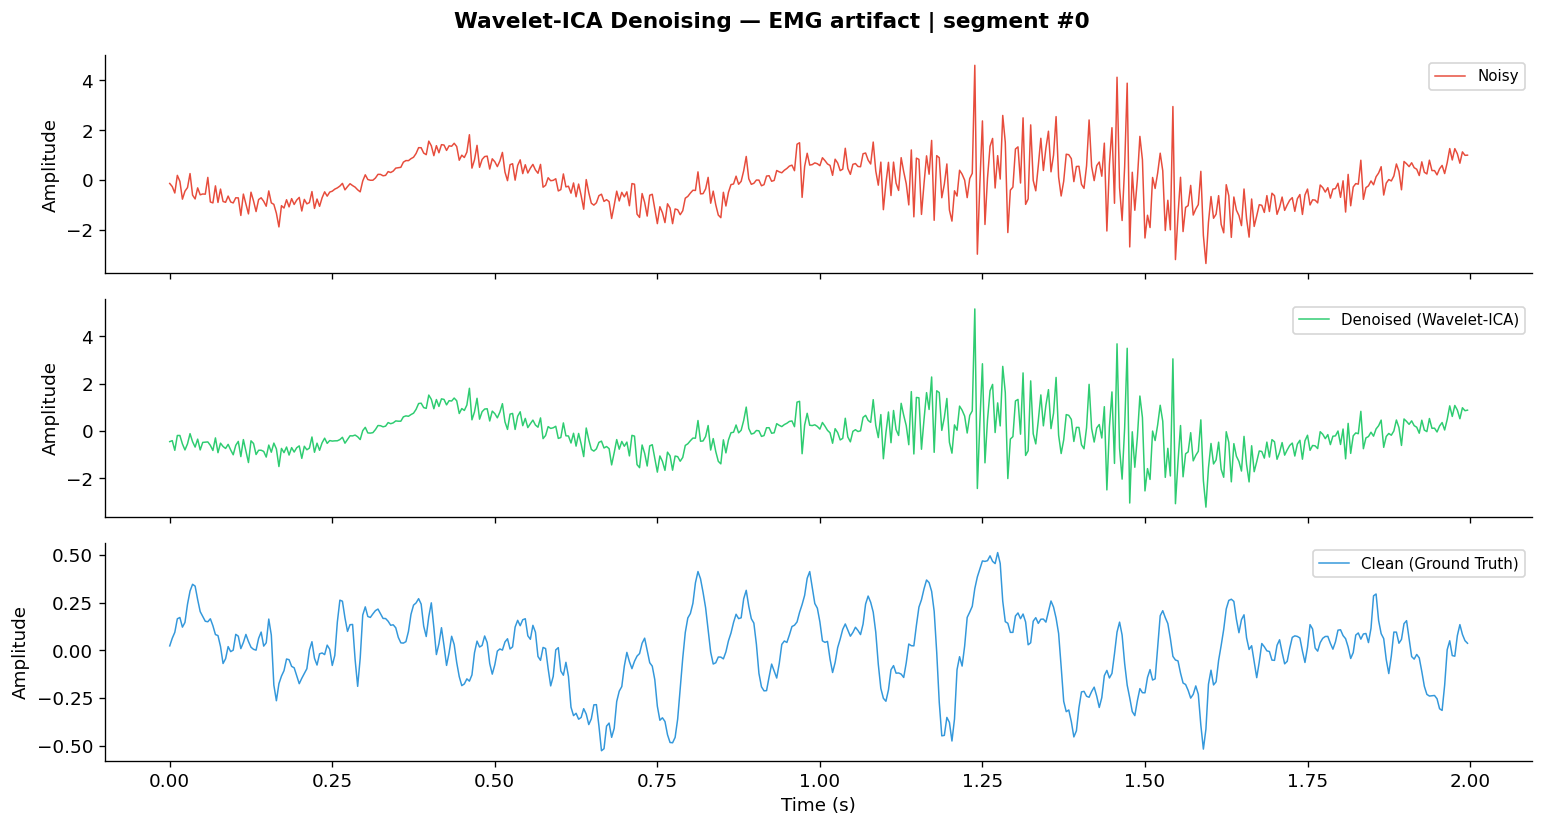


Metrics for this single segment:
  MSE            : 0.854893
  RMSE           : 0.924604
  RRMSE          : 4.745267
  SNR_dB         : -13.525213
  SpectralLoss   : 28.901253


In [34]:
# Denoise a single segment and plot
idx = 0
t = np.arange(512) / FS

denoised_single = wavelet_ica_denoise_single(noisy_demo[idx])

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)
axes[0].plot(t, noisy_demo[idx],  color='#e74c3c', lw=0.9, label='Noisy')
axes[1].plot(t, denoised_single,  color='#2ecc71', lw=0.9, label='Denoised (Wavelet-ICA)')
axes[2].plot(t, clean_demo[idx],  color='#3498db', lw=0.9, label='Clean (Ground Truth)')
for ax in axes:
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylabel('Amplitude')
axes[2].set_xlabel('Time (s)')
fig.suptitle(f'Wavelet-ICA Denoising — {DEMO_COMBO.upper()} artifact | segment #{idx}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_single_segment.png', bbox_inches='tight')
plt.show()

m = all_metrics(clean_demo[[idx]], denoised_single[np.newaxis, :])
print('\nMetrics for this single segment:')
for k, v in m.items():
    print(f'  {k:<15}: {v:.6f}')

## 5 · Spectral Visualisation (Frequency Domain)

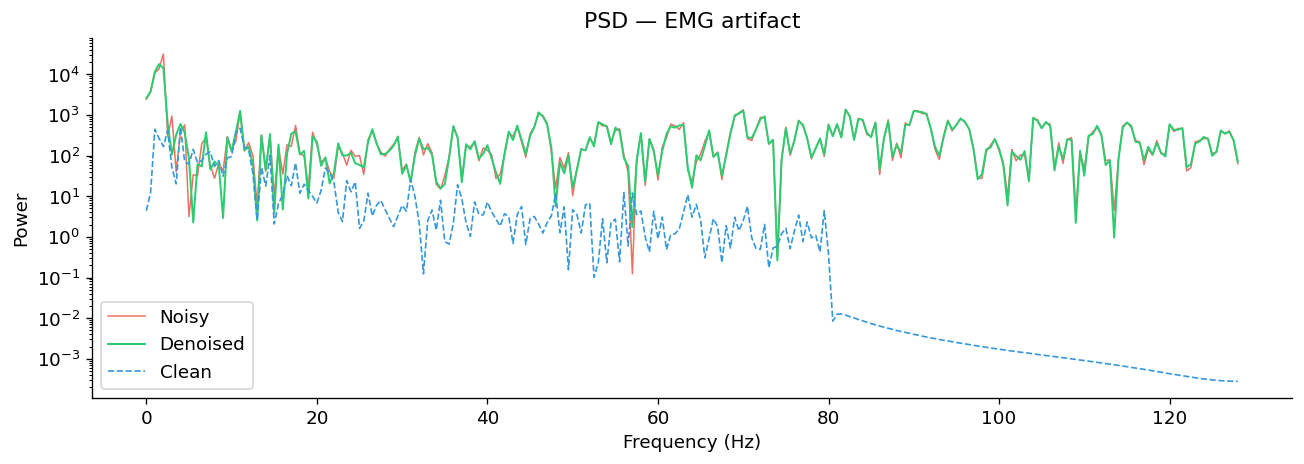

In [35]:
def plot_psd(clean_1d, noisy_1d, denoised_1d, fs=FS, title=''):
    freqs  = np.fft.rfftfreq(512, d=1/fs)
    psd_c  = np.abs(np.fft.rfft(clean_1d)) ** 2
    psd_n  = np.abs(np.fft.rfft(noisy_1d)) ** 2
    psd_d  = np.abs(np.fft.rfft(denoised_1d)) ** 2

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.semilogy(freqs, psd_n, color='#e74c3c', lw=0.9, alpha=0.8, label='Noisy')
    ax.semilogy(freqs, psd_d, color='#2ecc71', lw=1.2, label='Denoised')
    ax.semilogy(freqs, psd_c, color='#3498db', lw=1.0, ls='--', label='Clean')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Power')
    ax.set_title(title or 'Power Spectral Density')
    ax.legend()
    plt.tight_layout()
    plt.savefig('demo_psd.png', bbox_inches='tight')
    plt.show()

plot_psd(
    clean_demo[0], noisy_demo[0], denoised_single,
    title=f'PSD — {DEMO_COMBO.upper()} artifact'
)

## 6 · Full Evaluation Across All Combos & Splits

In [36]:
results = []  # will accumulate dicts

combo_bar = tqdm(COMBOS, desc='Combos', unit='combo', position=0)

for combo in combo_bar:
    combo_bar.set_postfix(combo=combo)

    split_bar = tqdm(SPLITS, desc=f'  Splits [{combo}]', unit='split',
                     position=1, leave=False)

    for split in split_bar:
        split_bar.set_postfix(split=split)

        # ── Load ────────────────────────────────────────────────
        try:
            clean, noisy = load_h5(combo, split)
        except FileNotFoundError as e:
            tqdm.write(f'  [SKIP] {e}')
            continue

        # ── Optional subsample for speed ────────────────────────
        N = clean.shape[0]
        if MAX_EVAL_SAMPLES and N > MAX_EVAL_SAMPLES:
            rng = np.random.default_rng(SEED)
            idx = rng.choice(N, MAX_EVAL_SAMPLES, replace=False)
            clean = clean[idx]
            noisy = noisy[idx]
            tqdm.write(f'  [{combo}/{split}] subsampled {MAX_EVAL_SAMPLES}/{N} segments')

        # ── Denoise ─────────────────────────────────────────────
        t0 = time.time()
        denoised = denoise_batch(
            noisy,
            desc=f'{combo}/{split}',
        )
        elapsed = time.time() - t0

        # ── Metrics ─────────────────────────────────────────────
        m = all_metrics(clean, denoised)
        m['combo']        = combo
        m['split']        = split
        m['n_segments']   = clean.shape[0]
        m['elapsed_s']    = round(elapsed, 2)
        m['seg_per_sec']  = round(clean.shape[0] / elapsed, 1)
        results.append(m)

        tqdm.write(
            f'  {combo:>11}/{split:<5}  '
            f'SNR={m["SNR_dB"]:+.2f} dB  '
            f'RRMSE={m["RRMSE"]:.4f}  '
            f'SpecLoss={m["SpectralLoss"]:.3f}  '
            f'[{elapsed:.1f}s]'
        )

combo_bar.close()
print('\n✓ Evaluation complete.')

Combos:   0%|          | 0/7 [00:00<?, ?combo/s]

  Splits [emg]:   0%|          | 0/1 [00:00<?, ?split/s]

emg/test:   0%|          | 0/4520 [00:00<?, ?seg/s]

          emg/test   SNR=-5.15 dB  RRMSE=2.1805  SpecLoss=19.837  [211.2s]


  Splits [eog]:   0%|          | 0/1 [00:00<?, ?split/s]

...

eog_ecg/test:   0%|          | 0/4520 [00:00<?, ?seg/s]

      eog_ecg/test   SNR=-7.60 dB  RRMSE=2.9180  SpecLoss=6.638  [195.8s]


  Splits [emg_eog_ecg]:   0%|          | 0/1 [00:00<?, ?split/s]

emg_eog_ecg/test:   0%|          | 0/4520 [00:00<?, ?seg/s]

  emg_eog_ecg/test   SNR=-9.40 dB  RRMSE=3.6059  SpecLoss=20.359  [186.2s]

✓ Evaluation complete.


## 7 · Results Table

In [37]:
df = pd.DataFrame(results)
cols_order = ['combo', 'split', 'n_segments', 'MSE', 'RMSE', 'RRMSE',
              'SNR_dB', 'SpectralLoss', 'elapsed_s', 'seg_per_sec']
df = df[cols_order]

pd.set_option('display.float_format', '{:.5f}'.format)
pd.set_option('display.max_rows', 50)
print(df.to_string(index=False))

# Save
df.to_csv('wavelet_ica_metrics.csv', index=False)
print('\nSaved: wavelet_ica_metrics.csv')

      combo split  n_segments     MSE    RMSE   RRMSE   SNR_dB  SpectralLoss  elapsed_s  seg_per_sec
        emg  test        4520 0.70694 0.84080 2.18047 -5.15242      19.83734  211.23000     21.40000
        eog  test        4520 0.64751 0.80468 2.05415 -4.68950       5.13510  213.01000     21.20000
        ecg  test        4520 1.41777 1.19070 2.10763 -4.88085       5.69709  192.97000     23.40000
    emg_eog  test        4520 0.76009 0.87183 2.96112 -7.73149      19.98501  196.84000     23.00000
    emg_ecg  test        4520 0.96958 0.98467 2.99327 -7.82617      20.42426  186.22000     24.30000
    eog_ecg  test        4520 0.94637 0.97281 2.91795 -7.59849       6.63843  195.82000     23.10000
emg_eog_ecg  test        4520 0.92966 0.96419 3.60591 -9.40062      20.35876  186.19000     24.30000

Saved: wavelet_ica_metrics.csv


In [38]:
# Pivot: test-split summary (one row per combo)
test_df = df[df['split'] == 'test'].copy()
print('=== TEST SPLIT SUMMARY ===')
print(test_df[['combo', 'MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'SpectralLoss']]
      .sort_values('SNR_dB', ascending=False)
      .to_string(index=False))

=== TEST SPLIT SUMMARY ===
      combo     MSE    RMSE   RRMSE   SNR_dB  SpectralLoss
        eog 0.64751 0.80468 2.05415 -4.68950       5.13510
        ecg 1.41777 1.19070 2.10763 -4.88085       5.69709
        emg 0.70694 0.84080 2.18047 -5.15242      19.83734
    eog_ecg 0.94637 0.97281 2.91795 -7.59849       6.63843
    emg_eog 0.76009 0.87183 2.96112 -7.73149      19.98501
    emg_ecg 0.96958 0.98467 2.99327 -7.82617      20.42426
emg_eog_ecg 0.92966 0.96419 3.60591 -9.40062      20.35876


## 8 · Visualisations

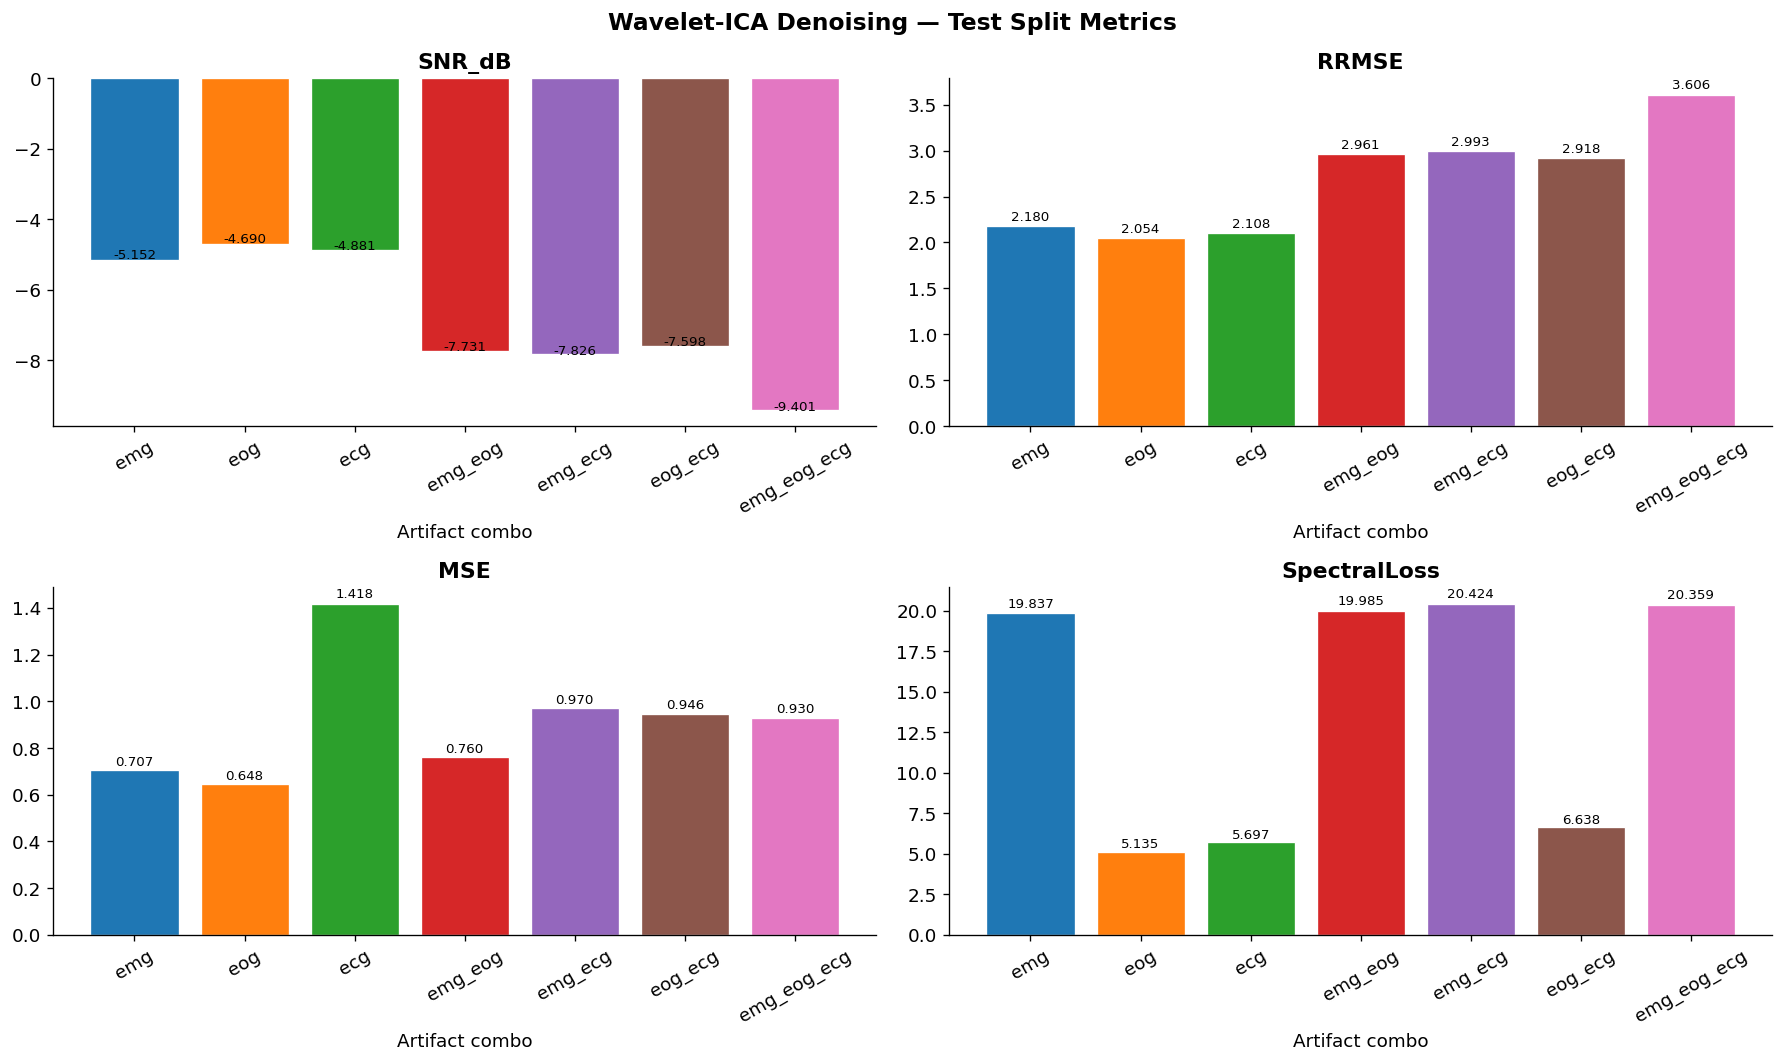

In [39]:
# ── Bar charts: test-split metrics per combo ──────────────────────────────────

metrics_to_plot = ['SNR_dB', 'RRMSE', 'MSE', 'SpectralLoss']
palette = sns.color_palette('tab10', n_colors=len(test_df))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        test_df['combo'], test_df[metric],
        color=palette, edgecolor='white', linewidth=0.8
    )
    # Value labels
    for bar, val in zip(bars, test_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8
        )
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Artifact combo')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Wavelet-ICA Denoising — Test Split Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_bar_test.png', bbox_inches='tight')
plt.show()

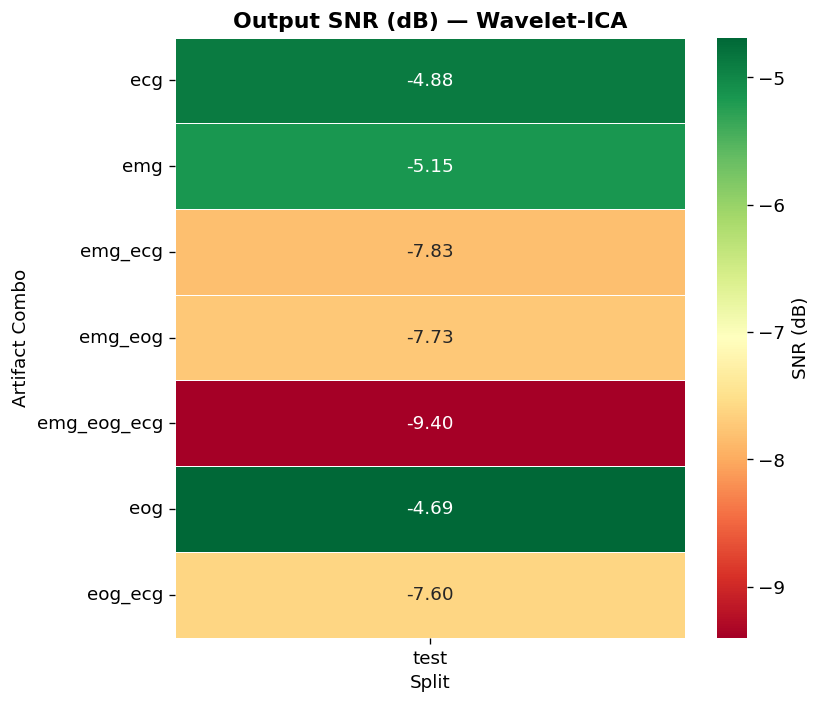

In [41]:
# ── Heatmap: SNR_dB across combos × splits ───────────────────────────────────

pivot_snr = df.pivot(index='combo', columns='split', values='SNR_dB')
# Reorder splits
pivot_snr = pivot_snr[['test']]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    pivot_snr, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'SNR (dB)'}
)
ax.set_title('Output SNR (dB) — Wavelet-ICA', fontweight='bold')
ax.set_xlabel('Split'); ax.set_ylabel('Artifact Combo')
plt.tight_layout()
plt.savefig('heatmap_snr.png', bbox_inches='tight')
plt.show()

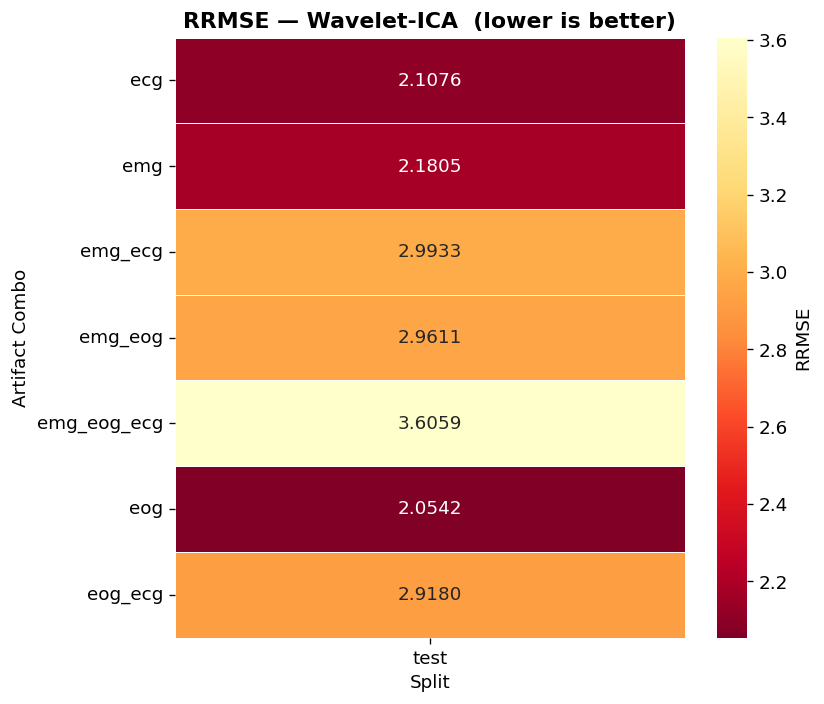

In [43]:
# ── Heatmap: RRMSE across combos × splits ────────────────────────────────────

pivot_rrmse = df.pivot(index='combo', columns='split', values='RRMSE')
pivot_rrmse = pivot_rrmse[['test']]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    pivot_rrmse, annot=True, fmt='.4f', cmap='YlOrRd_r',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'RRMSE'}
)
ax.set_title('RRMSE — Wavelet-ICA  (lower is better)', fontweight='bold')
ax.set_xlabel('Split'); ax.set_ylabel('Artifact Combo')
plt.tight_layout()
plt.savefig('heatmap_rrmse.png', bbox_inches='tight')
plt.show()

Plotting combos:   0%|          | 0/7 [00:00<?, ?it/s]

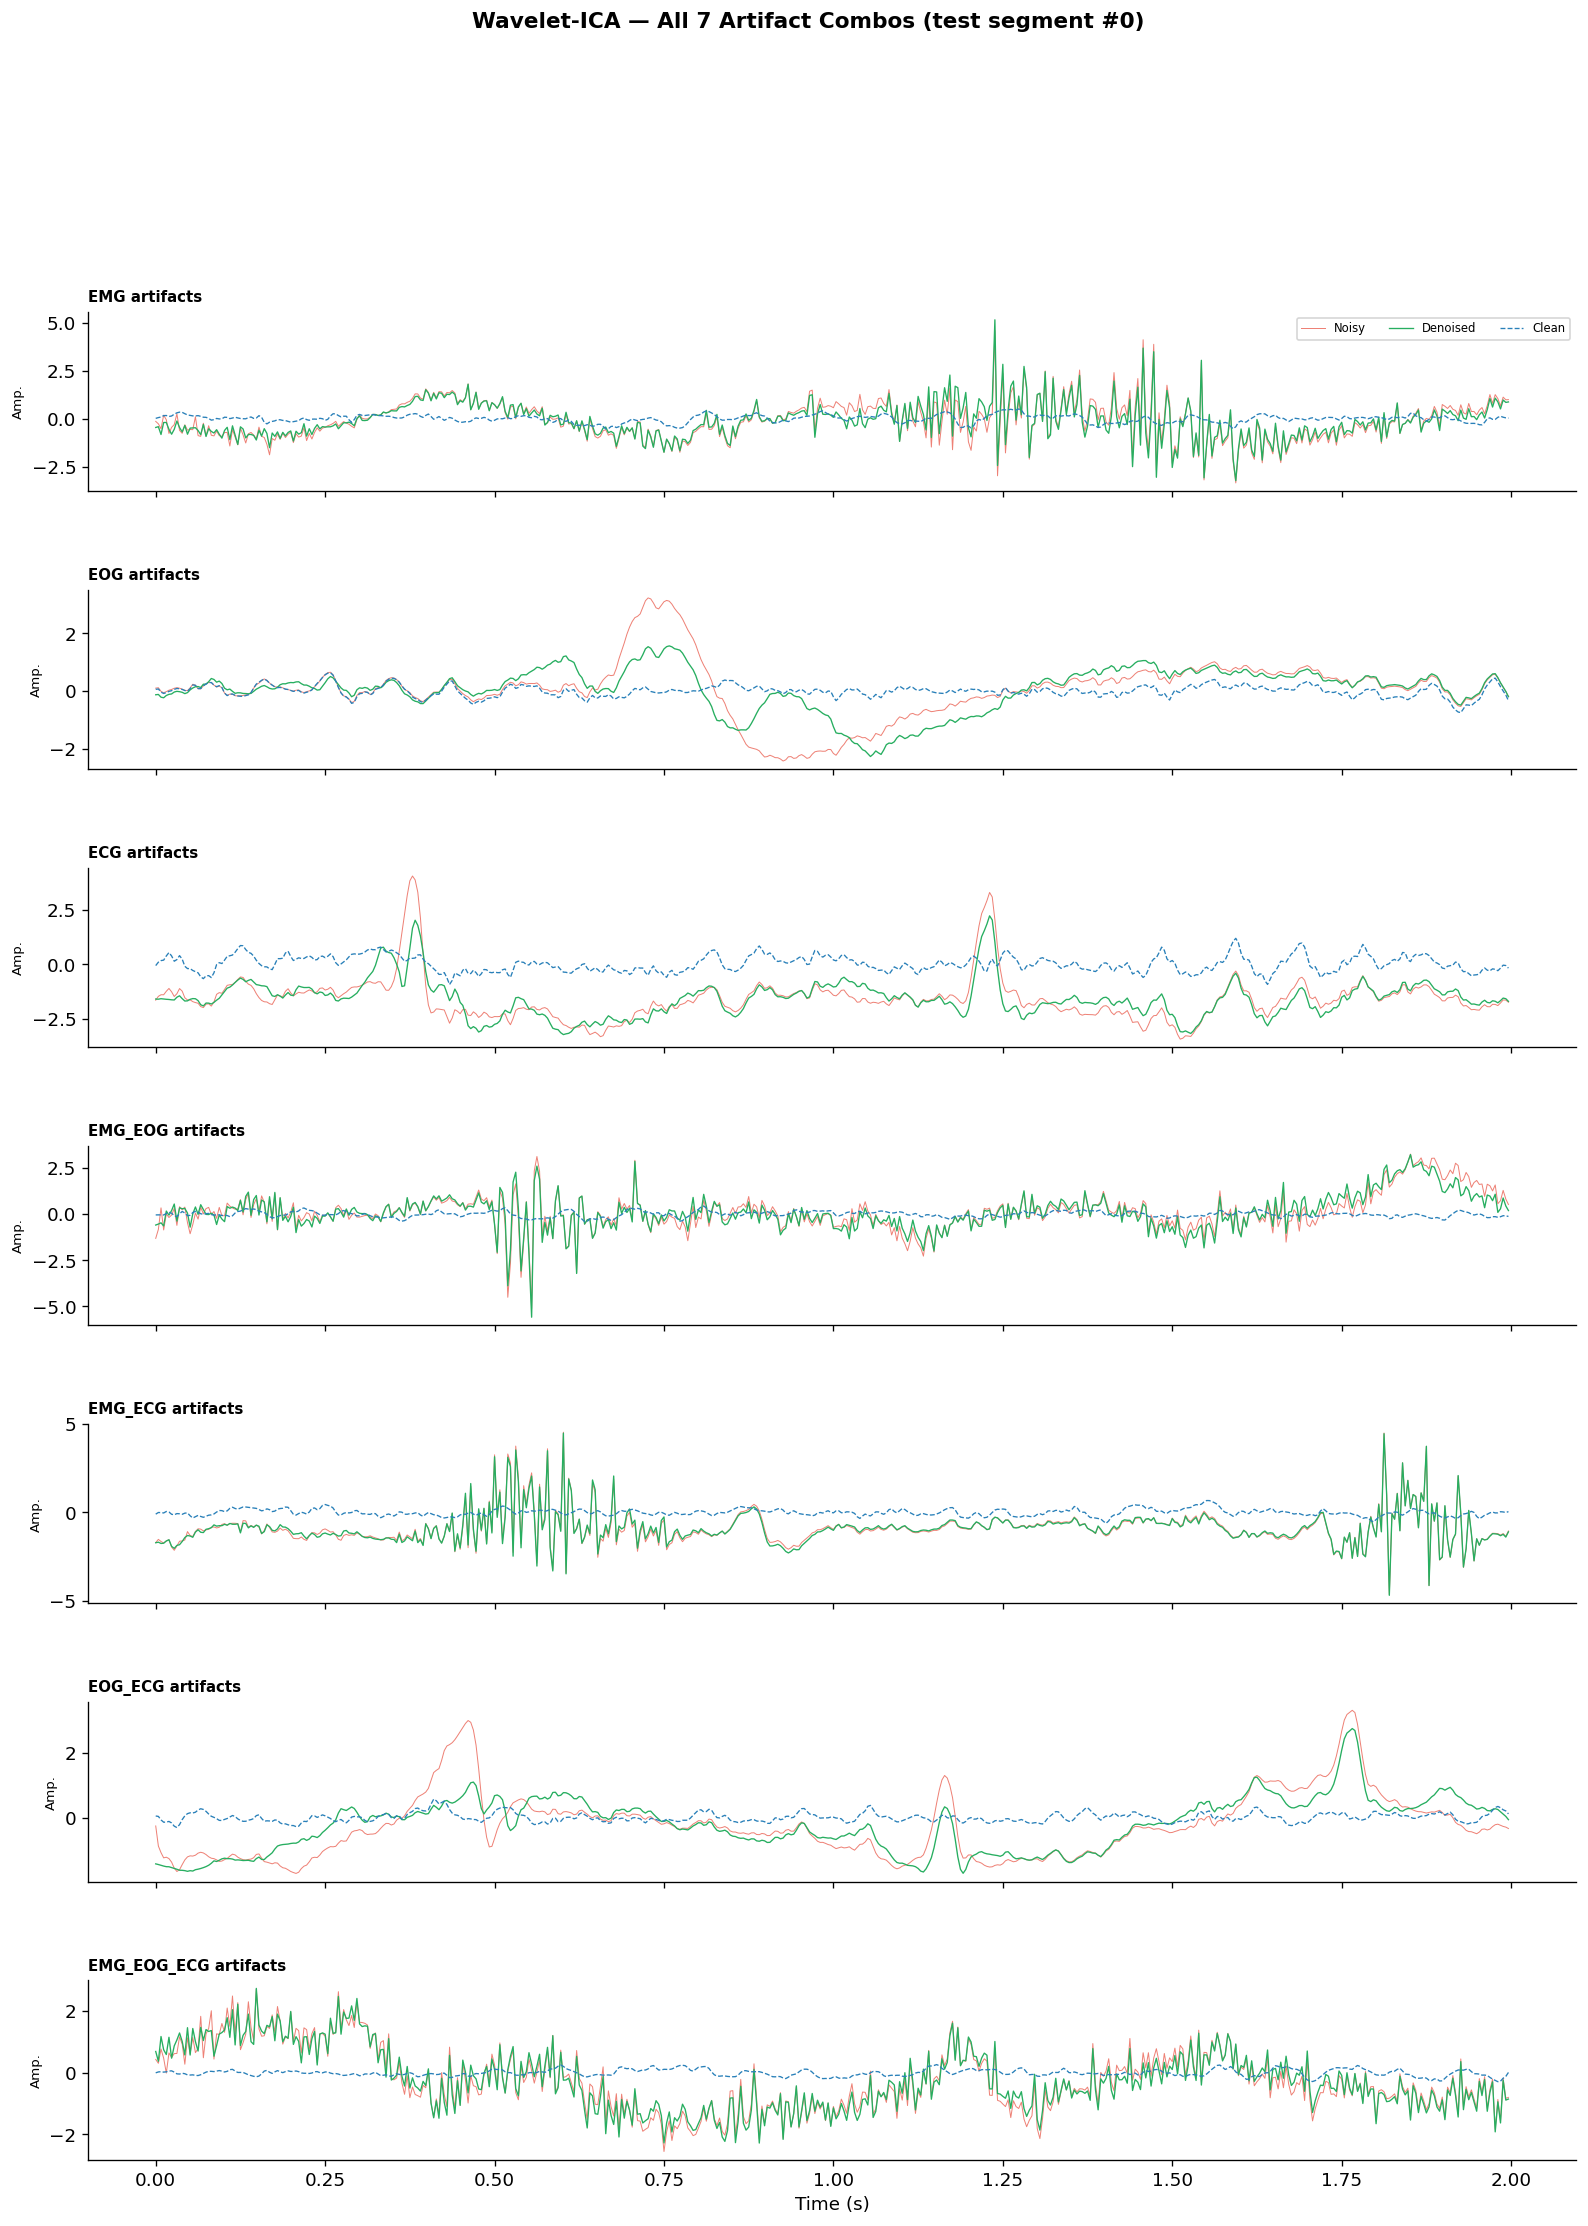

In [44]:
# ── Side-by-side waveform grid for all 7 combos (test split, segment 0) ──────

fig = plt.figure(figsize=(16, 20))
gs  = gridspec.GridSpec(7, 1, hspace=0.55)
t   = np.arange(512) / FS

for row_i, combo in enumerate(tqdm(COMBOS, desc='Plotting combos')):
    try:
        clean_c, noisy_c = load_h5(combo, 'test')
    except FileNotFoundError:
        continue

    seg_c  = clean_c[0]
    seg_n  = noisy_c[0]
    seg_d  = wavelet_ica_denoise_single(seg_n)

    ax = fig.add_subplot(gs[row_i])
    ax.plot(t, seg_n, color='#e74c3c', lw=0.6, alpha=0.7, label='Noisy')
    ax.plot(t, seg_d, color='#27ae60', lw=0.8,             label='Denoised')
    ax.plot(t, seg_c, color='#2980b9', lw=0.8, ls='--',    label='Clean')
    ax.set_ylabel('Amp.', fontsize=8)
    ax.set_title(f'{combo.upper()} artifacts', fontsize=9, fontweight='bold', loc='left')
    if row_i == 0:
        ax.legend(loc='upper right', fontsize=7, ncol=3)
    if row_i < 6:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)')

fig.suptitle('Wavelet-ICA — All 7 Artifact Combos (test segment #0)',
             fontsize=13, fontweight='bold', y=1.005)
plt.savefig('waveform_grid_all_combos.png', bbox_inches='tight')
plt.show()

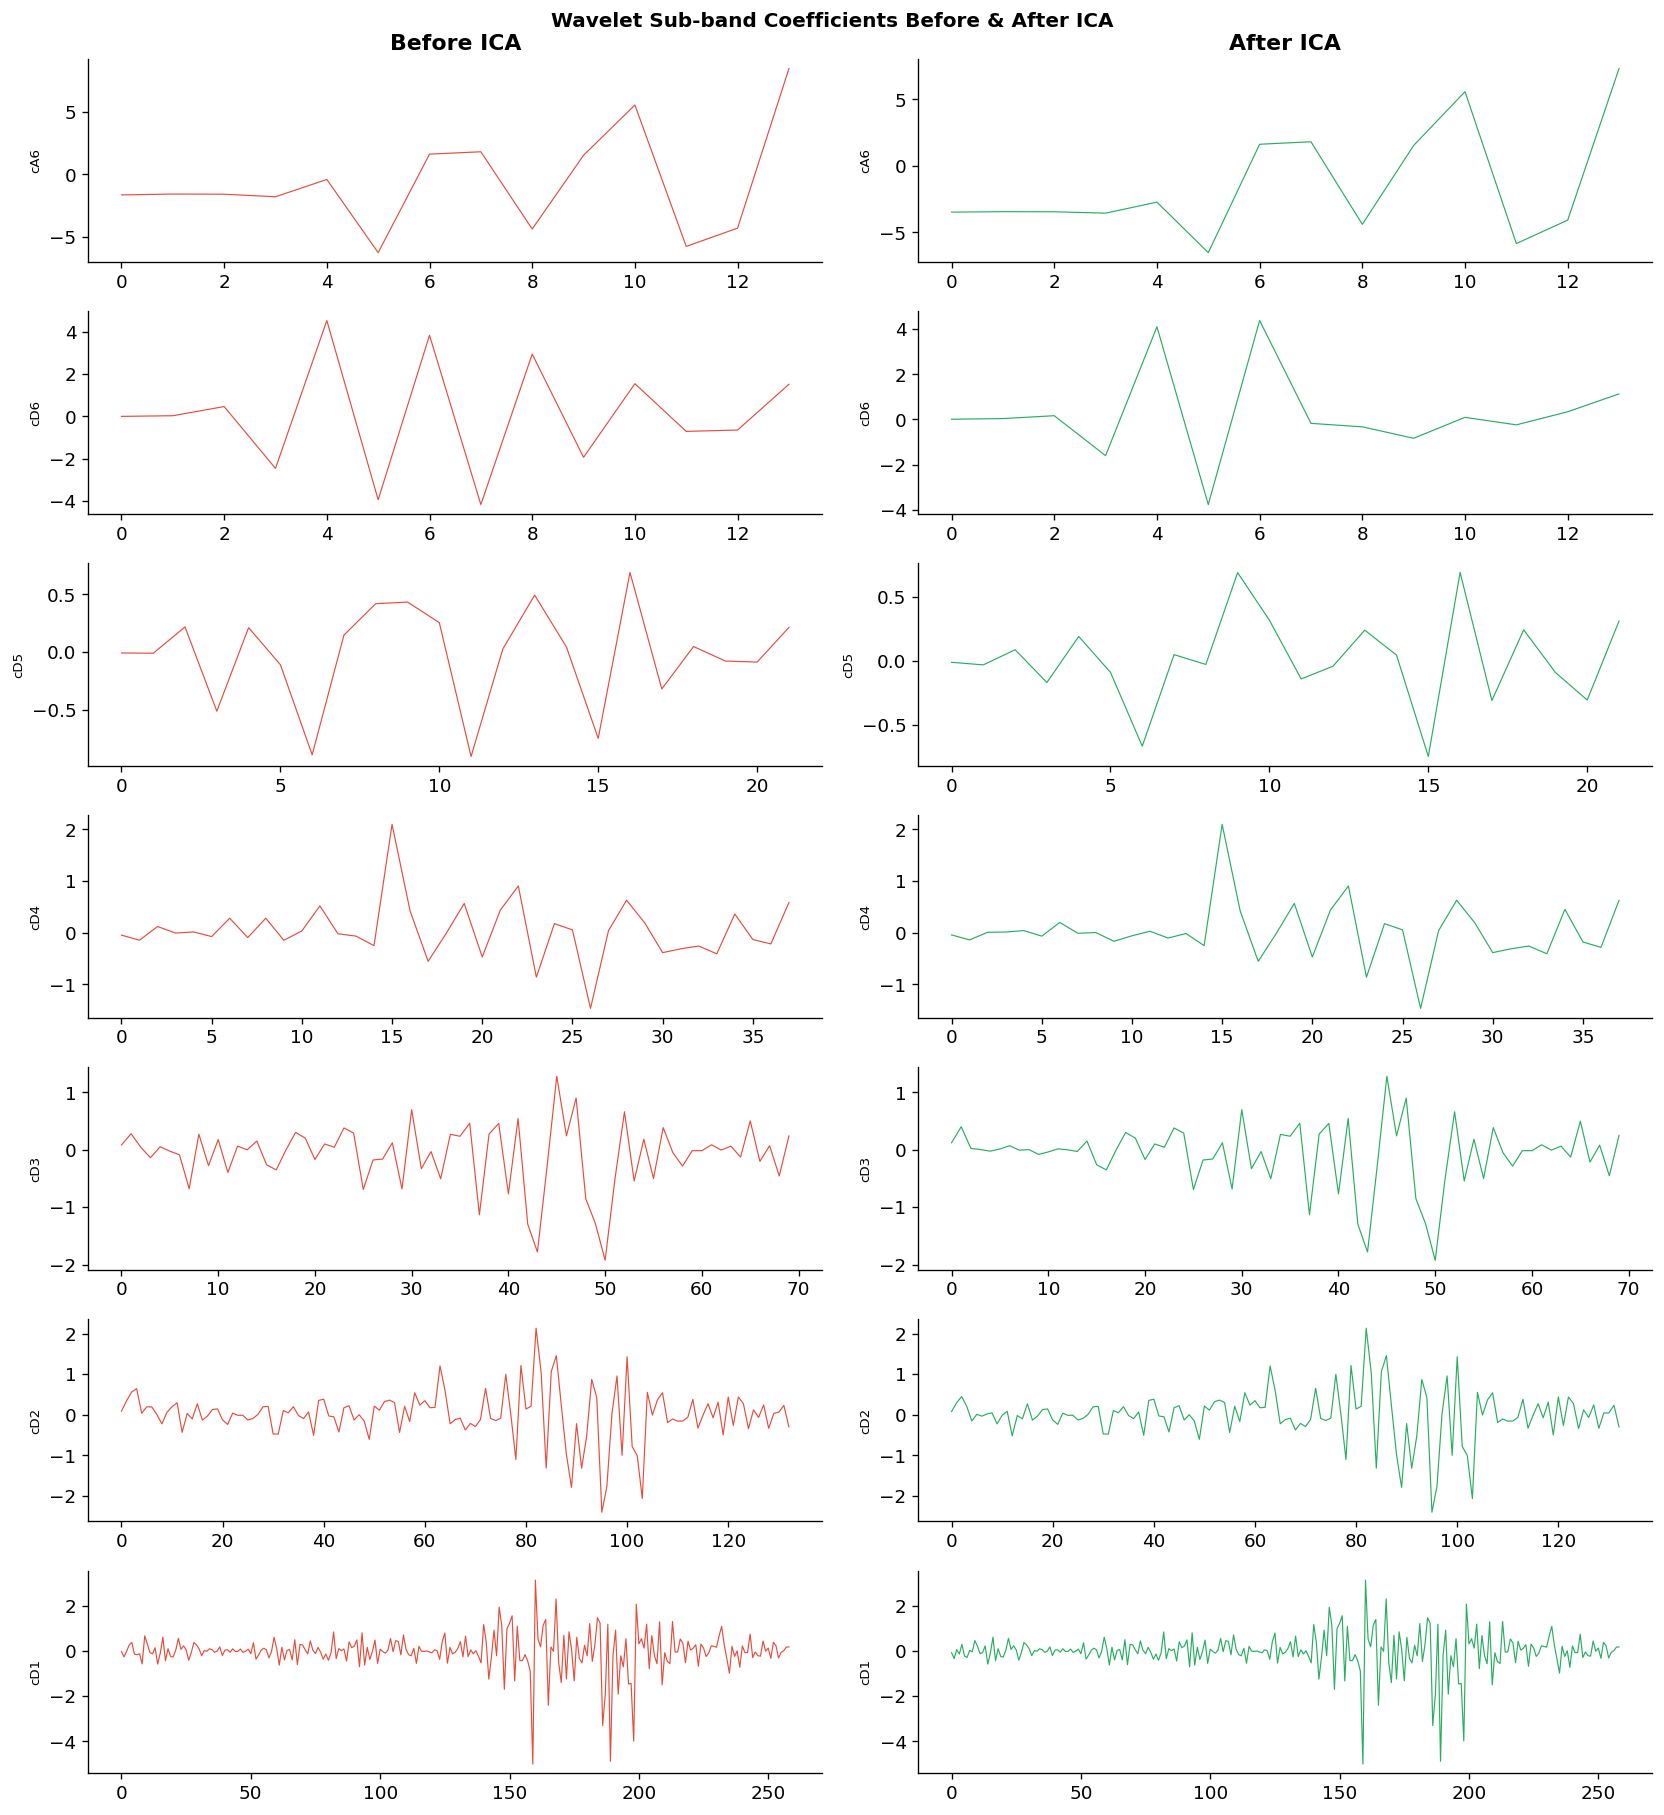

In [45]:
# ── Wavelet coefficient visualisation (before vs after ICA) ──────────────────

seg = noisy_demo[0]
coeffs_before = pywt.wavedec(seg, wavelet=WAVELET, level=LEVEL)
coeffs_after  = pywt.wavedec(
    wavelet_ica_denoise_single(seg), wavelet=WAVELET, level=LEVEL
)

n_bands = LEVEL + 1  # cA + cD_L … cD_1
labels  = [f'cA{LEVEL}'] + [f'cD{LEVEL - i}' for i in range(LEVEL)]

fig, axes = plt.subplots(n_bands, 2, figsize=(14, 2.2 * n_bands), sharex=False)
for i in range(n_bands):
    for j, (coeff, title) in enumerate([
        (coeffs_before[i], 'Before ICA'),
        (coeffs_after[i],  'After ICA')
    ]):
        axes[i, j].plot(coeff, lw=0.7,
                        color='#e74c3c' if j == 0 else '#27ae60')
        axes[i, j].set_ylabel(labels[i], fontsize=8)
        if i == 0:
            axes[i, j].set_title(title, fontweight='bold')

fig.suptitle('Wavelet Sub-band Coefficients Before & After ICA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('wavelet_subbands.png', bbox_inches='tight')
plt.show()

## 9 · Per-Metric Summary Statistics

In [46]:
metric_cols = ['MSE', 'RMSE', 'RRMSE', 'SNR_dB', 'SpectralLoss']

print('=== Overall mean (all combos, all splits) ===')
print(df[metric_cols].mean().to_string())

print('\n=== Mean per split ===')
print(df.groupby('split')[metric_cols].mean().to_string())

print('\n=== Mean per combo (test only) ===')
print(df[df['split'] == 'test'].groupby('combo')[metric_cols].mean().to_string())

=== Overall mean (all combos, all splits) ===
MSE             0.91113
RMSE            0.94710
RRMSE           2.68864
SNR_dB         -6.75422
SpectralLoss   14.01086

=== Mean per split ===
          MSE    RMSE   RRMSE   SNR_dB  SpectralLoss
split                                               
test  0.91113 0.94710 2.68864 -6.75422      14.01086

=== Mean per combo (test only) ===
                MSE    RMSE   RRMSE   SNR_dB  SpectralLoss
combo                                                     
ecg         1.41777 1.19070 2.10763 -4.88085       5.69709
emg         0.70694 0.84080 2.18047 -5.15242      19.83734
emg_ecg     0.96958 0.98467 2.99327 -7.82617      20.42426
emg_eog     0.76009 0.87183 2.96112 -7.73149      19.98501
emg_eog_ecg 0.92966 0.96419 3.60591 -9.40062      20.35876
eog         0.64751 0.80468 2.05415 -4.68950       5.13510
eog_ecg     0.94637 0.97281 2.91795 -7.59849       6.63843


Input SNR baseline:   0%|          | 0/7 [00:00<?, ?it/s]

=== SNR Improvement (test split) ===
      combo  Output_SNR_dB  Input_SNR_dB  SNR_improvement_dB
        emg       -5.15242      -5.00000            -0.15242
        eog       -4.68950      -5.00000             0.31050
        ecg       -4.88085      -5.00000             0.11915
    emg_eog       -7.73149      -7.96794             0.23645
    emg_ecg       -7.82617      -8.00007             0.17390
    eog_ecg       -7.59849      -7.96355             0.36505
emg_eog_ecg       -9.40062      -9.70375             0.30313


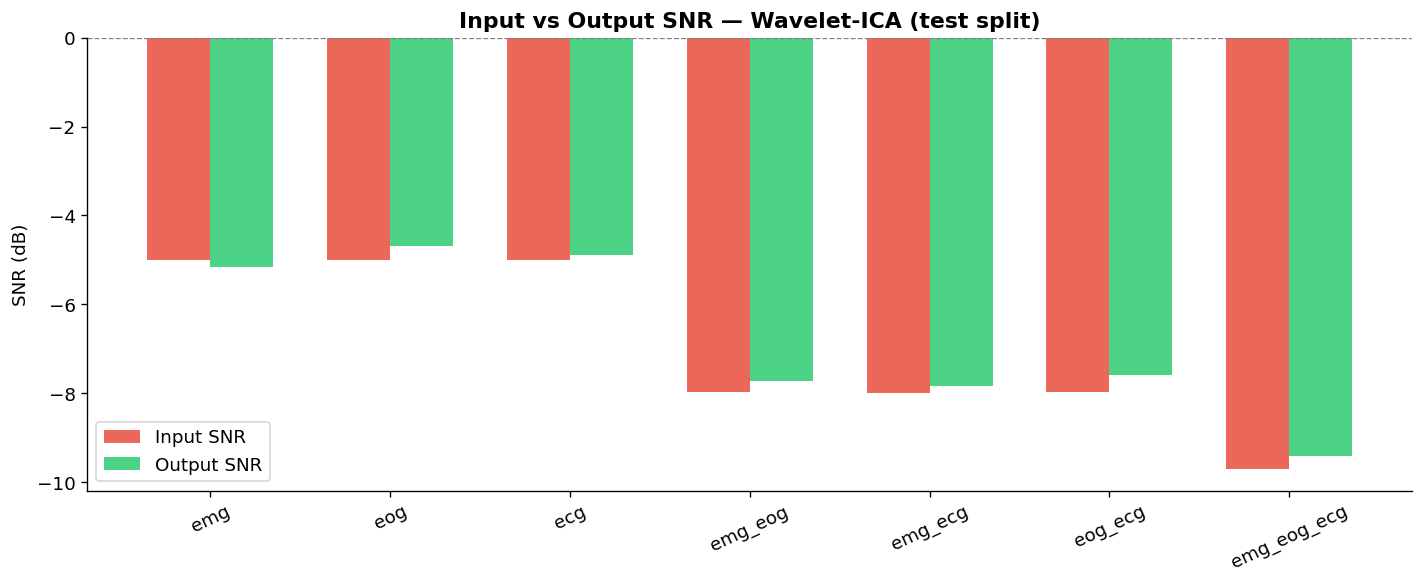

In [47]:
# ── SNR improvement: compare noisy baseline vs denoised ──────────────────────
# Re-compute SNR of noisy signal (input SNR) for the test split

input_snrs = []
for combo in tqdm(COMBOS, desc='Input SNR baseline'):
    try:
        clean, noisy = load_h5(combo, 'test')
        if MAX_EVAL_SAMPLES and clean.shape[0] > MAX_EVAL_SAMPLES:
            rng = np.random.default_rng(SEED)
            idx = rng.choice(clean.shape[0], MAX_EVAL_SAMPLES, replace=False)
            clean, noisy = clean[idx], noisy[idx]
        input_snr = compute_snr_db(clean, noisy)  # noisy as the "estimate"
        input_snrs.append({'combo': combo, 'Input_SNR_dB': input_snr})
    except FileNotFoundError:
        pass

df_input = pd.DataFrame(input_snrs)
df_test  = test_df[['combo', 'SNR_dB']].rename(columns={'SNR_dB': 'Output_SNR_dB'})
df_snr   = df_test.merge(df_input, on='combo')
df_snr['SNR_improvement_dB'] = df_snr['Output_SNR_dB'] - df_snr['Input_SNR_dB']

print('=== SNR Improvement (test split) ===')
print(df_snr.to_string(index=False))

# Plot
x = np.arange(len(df_snr))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, df_snr['Input_SNR_dB'],  width=w, label='Input SNR',  color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, df_snr['Output_SNR_dB'], width=w, label='Output SNR', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(df_snr['combo'], rotation=25)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('SNR (dB)')
ax.set_title('Input vs Output SNR — Wavelet-ICA (test split)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('snr_improvement.png', bbox_inches='tight')
plt.show()

## 10 · Save Denoised Outputs (Optional)

In [48]:
# Uncomment to save denoised test arrays as HDF5 for downstream use

# OUTPUT_DIR = '/kaggle/working/denoised'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# for combo in tqdm(COMBOS, desc='Saving denoised outputs'):
#     try:
#         clean, noisy = load_h5(combo, 'test')
#     except FileNotFoundError:
#         continue
#     denoised = denoise_batch(noisy, desc=combo)
#     out_path = os.path.join(OUTPUT_DIR, f'{combo}_test_denoised.h5')
#     with h5py.File(out_path, 'w') as f:
#         f.create_dataset('clean',    data=clean,    compression='gzip')
#         f.create_dataset('noisy',    data=noisy,    compression='gzip')
#         f.create_dataset('denoised', data=denoised, compression='gzip')
#     print(f'Saved: {out_path}')

print('(Saving block is commented out — uncomment to enable.)')

(Saving block is commented out — uncomment to enable.)


## 11 · Hyperparameter Sensitivity (Optional)

Kurtosis sweep:   0%|          | 0/7 [00:00<?, ?it/s]

kurt=1.5:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=2.0:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=2.5:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=3.0:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=3.5:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=4.0:   0%|          | 0/500 [00:00<?, ?seg/s]

kurt=5.0:   0%|          | 0/500 [00:00<?, ?seg/s]

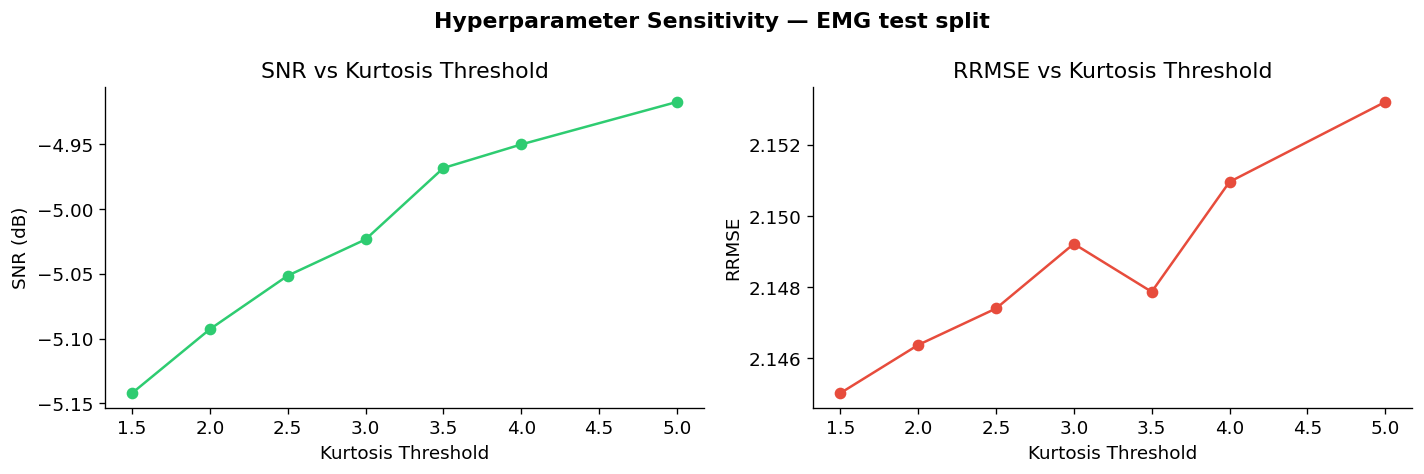

 kurtosis_thresh   SNR_dB   RRMSE  SpectralLoss
         1.50000 -5.14215 2.14502      19.52655
         2.00000 -5.09280 2.14637      19.53095
         2.50000 -5.05147 2.14740      19.53503
         3.00000 -5.02348 2.14922      19.54027
         3.50000 -4.96836 2.14787      19.53615
         4.00000 -4.95016 2.15096      19.54559
         5.00000 -4.91736 2.15321      19.54625


In [49]:
# Quick sweep over kurtosis threshold on a small subset of emg/test

SWEEP_N = 500   # segments
THRESHOLDS = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]

try:
    clean_sw, noisy_sw = load_h5('emg', 'test')
    rng = np.random.default_rng(SEED)
    idx = rng.choice(clean_sw.shape[0], SWEEP_N, replace=False)
    clean_sw, noisy_sw = clean_sw[idx], noisy_sw[idx]

    sweep_rows = []
    for thresh in tqdm(THRESHOLDS, desc='Kurtosis sweep'):
        den = denoise_batch(noisy_sw, kurtosis_thresh=thresh, desc=f'kurt={thresh}')
        m = all_metrics(clean_sw, den)
        m['kurtosis_thresh'] = thresh
        sweep_rows.append(m)

    df_sweep = pd.DataFrame(sweep_rows)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(df_sweep['kurtosis_thresh'], df_sweep['SNR_dB'], 'o-', color='#2ecc71')
    axes[0].set_xlabel('Kurtosis Threshold'); axes[0].set_ylabel('SNR (dB)')
    axes[0].set_title('SNR vs Kurtosis Threshold')

    axes[1].plot(df_sweep['kurtosis_thresh'], df_sweep['RRMSE'], 'o-', color='#e74c3c')
    axes[1].set_xlabel('Kurtosis Threshold'); axes[1].set_ylabel('RRMSE')
    axes[1].set_title('RRMSE vs Kurtosis Threshold')

    plt.suptitle('Hyperparameter Sensitivity — EMG test split', fontweight='bold')
    plt.tight_layout()
    plt.savefig('hyperparam_sweep.png', bbox_inches='tight')
    plt.show()

    print(df_sweep[['kurtosis_thresh', 'SNR_dB', 'RRMSE', 'SpectralLoss']].to_string(index=False))

except FileNotFoundError as e:
    print(f'Skipping sweep: {e}')

## 12 · Final Summary

In [50]:
print('╔══════════════════════════════════════════════════════════╗')
print('║         WAVELET-ICA DENOISING — FINAL SUMMARY           ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Wavelet : {WAVELET:<6}  Levels : {LEVEL}                           ║')
print(f'║  Kurtosis threshold : {KURTOSIS_THRESH}                              ║')
print('╠══════════════════════════════════════════════════════════╣')

test_df_sorted = df[df['split'] == 'test'].sort_values('SNR_dB', ascending=False)
for _, row in test_df_sorted.iterrows():
    print(
        f'║  {row["combo"]:>11}  '
        f'SNR={row["SNR_dB"]:+6.2f} dB  '
        f'RRMSE={row["RRMSE"]:.4f}  '
        f'SpecLoss={row["SpectralLoss"]:.3f}  ║'
    )

print('╠══════════════════════════════════════════════════════════╣')
avg = df[df['split'] == 'test'][metric_cols].mean()
print(f'║  MEAN (test)  SNR={avg["SNR_dB"]:+6.2f} dB  RRMSE={avg["RRMSE"]:.4f}           ║')
print('╚══════════════════════════════════════════════════════════╝')

print('\nOutput files:')
for f in [
    'wavelet_ica_metrics.csv',
    'demo_single_segment.png',
    'demo_psd.png',
    'metrics_bar_test.png',
    'heatmap_snr.png',
    'heatmap_rrmse.png',
    'waveform_grid_all_combos.png',
    'wavelet_subbands.png',
    'snr_improvement.png',
    'hyperparam_sweep.png',
]:
    exists = '✓' if os.path.exists(f) else '✗'
    print(f'  {exists}  {f}')

╔══════════════════════════════════════════════════════════╗
║         WAVELET-ICA DENOISING — FINAL SUMMARY           ║
╠══════════════════════════════════════════════════════════╣
║  Wavelet : db4     Levels : 6                           ║
║  Kurtosis threshold : 3.0                              ║
╠══════════════════════════════════════════════════════════╣
║          eog  SNR= -4.69 dB  RRMSE=2.0542  SpecLoss=5.135  ║
║          ecg  SNR= -4.88 dB  RRMSE=2.1076  SpecLoss=5.697  ║
║          emg  SNR= -5.15 dB  RRMSE=2.1805  SpecLoss=19.837  ║
║      eog_ecg  SNR= -7.60 dB  RRMSE=2.9180  SpecLoss=6.638  ║
║      emg_eog  SNR= -7.73 dB  RRMSE=2.9611  SpecLoss=19.985  ║
║      emg_ecg  SNR= -7.83 dB  RRMSE=2.9933  SpecLoss=20.424  ║
║  emg_eog_ecg  SNR= -9.40 dB  RRMSE=3.6059  SpecLoss=20.359  ║
╠══════════════════════════════════════════════════════════╣
║  MEAN (test)  SNR= -6.75 dB  RRMSE=2.6886           ║
╚══════════════════════════════════════════════════════════╝

Output files:


In [53]:
!ls | xargs zip wt_ica_results.zip

  adding: demo_psd.png (deflated 3%)
  adding: demo_single_segment.png (deflated 4%)
  adding: heatmap_rrmse.png (deflated 12%)
  adding: heatmap_snr.png (deflated 14%)
  adding: hyperparam_sweep.png (deflated 10%)
  adding: metrics_bar_test.png (deflated 19%)
  adding: snr_improvement.png (deflated 19%)
  adding: waveform_grid_all_combos.png (deflated 4%)
  adding: wavelet_ica_metrics.csv (deflated 46%)
  adding: wavelet_subbands.png (deflated 5%)
